# #30DayMapChallenge
## Day 28: Black

### Known Issues:
- Check for orientation of joyplot after plotting.
- If the raster is wider than taller, it may flip or rotate incorrectly.

### Setup

In [39]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pathlib import Path

In [150]:
def create_joy_plot(raster_file, num_ridges=40, spacing=500, amplitude_scale=1.0, 
                    border_width=0.25, border_height=0.25, 
                    flip_horizontal=None, flip_vertical=None):
    """
    Create a Joy Division style visualization from a raster DEM file.
    
    Parameters:
    -----------
    raster_file : str
        Path to the raster file (e.g., 'Matterhorn_clipped.tif')
    num_ridges : int
        Number of horizontal profile lines (default: 40)
    spacing : float
        Vertical spacing between each ridgeline (default: 500)
    amplitude_scale : float
        Scale the elevation changes (default: 1.0)
    border_width : float
        Border width as fraction of image width (default: 0.25)
    border_height : float
        Border height as fraction of image height (default: 0.25)
    flip_horizontal : bool or None
        Manually flip horizontally. None = auto-detect (default: None)
    flip_vertical : bool or None
        Manually flip vertically. None = auto-detect (default: None)
    
    Returns:
    --------
    str : Path to the saved output file
    """
    
    # Read the raster file
    with rasterio.open(raster_file) as src:
        dem = src.read(1).astype(float)
        transform = src.transform
        height, width = dem.shape
    
    # Sample coordinates at corners to understand orientation
    # Top-left corner (row=0, col=0)
    top_left_x, top_left_y = transform * (0, 0)
    # Top-right corner (row=0, col=width)
    top_right_x, top_right_y = transform * (width, 0)
    # Bottom-left corner (row=height, col=0)
    bottom_left_x, bottom_left_y = transform * (0, height)
    # Bottom-right corner (row=height, col=width)
    bottom_right_x, bottom_right_y = transform * (width, height)
    
    # Print diagnostic info
    print(f"Raster dimensions: {height} rows x {width} columns")
    print(f"\nCorner coordinates (in raster's CRS):")
    print(f"  Top-left:     ({top_left_x:.2f}, {top_left_y:.2f})")
    print(f"  Top-right:    ({top_right_x:.2f}, {top_right_y:.2f})")
    print(f"  Bottom-left:  ({bottom_left_x:.2f}, {bottom_left_y:.2f})")
    print(f"  Bottom-right: ({bottom_right_x:.2f}, {bottom_right_y:.2f})")
    
    # Determine geographic orientation
    # For horizontal: does x increase left-to-right?
    x_increases_left_to_right = top_right_x > top_left_x
    # For vertical: does y increase top-to-bottom (unusual) or decrease (normal)?
    y_increases_top_to_bottom = bottom_left_y > top_left_y
    
    print(f"\nGeographic orientation:")
    print(f"  X increases left-to-right: {x_increases_left_to_right}")
    print(f"  Y increases top-to-bottom: {y_increases_top_to_bottom}")
    print(f"\nFor Joy plots viewing south→north:")
    print(f"  We want lower Y values at bottom of plot (foreground)")
    print(f"  We want higher Y values at top of plot (background)")
        
    # Determine flips (manual override or auto-detect)
    if flip_horizontal is None:
        # Flip if x decreases left-to-right (we want west on left, east on right)
        flip_h = not x_increases_left_to_right
        print(f"✓ Auto-detect horizontal: {'flip' if flip_h else 'no flip'}")
    else:
        flip_h = flip_horizontal  # Manual override
        print(f"✓ Manual override horizontal: {'flip' if flip_h else 'no flip'}")
    
    if flip_vertical is None:
        # For Joy plots, we typically want to view from south (low Y) to north (high Y)
        # If Y increases top-to-bottom: don't flip (row 0 already has low Y)
        # If Y decreases top-to-bottom: flip (need to reverse so low Y is at bottom)
        flip_v = not y_increases_top_to_bottom
        print(f"✓ Auto-detect vertical: {'flip' if flip_v else 'no flip'} (for south→north view)")
    else:
        flip_v = flip_vertical  # Manual override
        print(f"✓ Manual override vertical: {'flip' if flip_v else 'no flip'}")
    
    # Apply flips
    if flip_h:
        dem = np.fliplr(dem)  # Flip left-right
    
    if flip_v:
        dem = np.flipud(dem)  # Flip up-down
    
    # Replace impossible values with NaN
    dem[dem <= -9999] = np.nan
    
    # Smooth the DEM
    dem_smooth = gaussian_filter(dem, sigma=1.0)
    
    # Sample rows evenly
    rows = np.linspace(0, dem_smooth.shape[0]-1, num_ridges).astype(int)
    
    # Create figure with black background
    fig, ax = plt.subplots(figsize=(14, 14), facecolor='black')
    ax.set_facecolor('black')
    
    offset = 0
    for i, r in enumerate(rows):
        profile = dem_smooth[r, :]
        
        # Normalize and scale the profile
        profile_norm = profile - np.nanmin(profile)
        profile_scaled = profile_norm * amplitude_scale
        
        x = np.arange(len(profile))
        
        # Plot the terrain profile
        ax.plot(x, profile_scaled + offset, color='white', linewidth=1.2)
        
        # Fill below to create masking effect (black fill hides lines behind)
        ax.fill_between(x, offset, profile_scaled + offset, color='black')
        
        offset += spacing
    
    # Add border/frame effect
    ax.set_xlim(-len(profile) * border_width, len(profile) * (1 + border_width))
    ax.set_ylim(-spacing * (1 + border_height), offset + spacing * (1 + border_height))
    ax.axis('off')
    plt.tight_layout(pad=0)
    
    # Generate output filename
    input_path = Path(raster_file)
    output_file = input_path.stem + '_joy_plot.png'
    
    # Save and show
    plt.savefig(output_file, dpi=300, facecolor='black', 
                bbox_inches='tight', pad_inches=0.5)
    plt.show()
    
    print(f"Visualization created with {num_ridges} profile lines")
    print(f"Saved to: {output_file}")
    
    return output_file

### Generate Joy Plots

Raster dimensions: 2665 rows x 5018 columns

Corner coordinates (in raster's CRS):
  Top-left:     (7.01, 46.41)
  Top-right:    (8.40, 46.41)
  Bottom-left:  (7.01, 45.67)
  Bottom-right: (8.40, 45.67)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


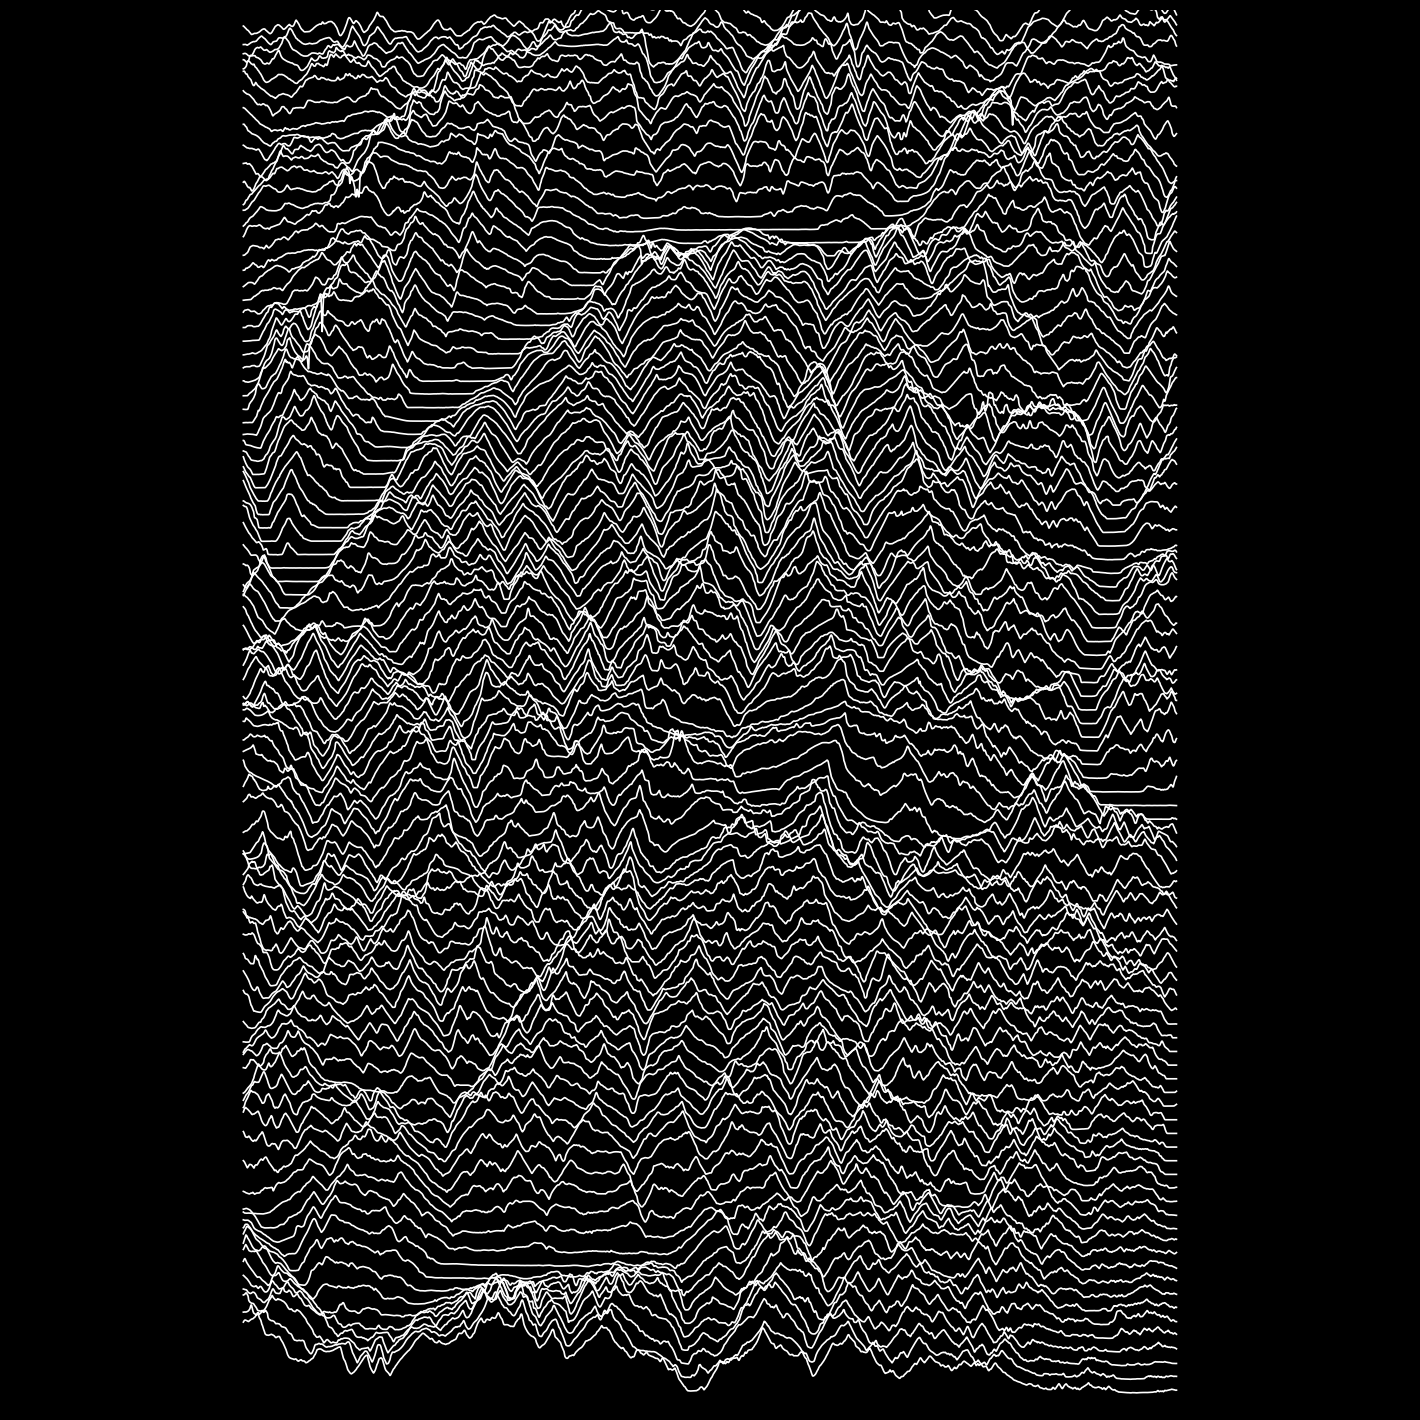

Visualization created with 100 profile lines
Saved to: Matterhorn_clipped_joy_plot.png


'Matterhorn_clipped_joy_plot.png'

In [93]:
create_joy_plot(
    raster_file="Matterhorn_clipped.tif",
    num_ridges=100,
    spacing=500,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25
)

Raster dimensions: 2484 rows x 4111 columns

Corner coordinates (in raster's CRS):
  Top-left:     (-6.79, 57.71)
  Top-right:    (-5.65, 57.71)
  Bottom-left:  (-6.79, 57.02)
  Bottom-right: (-5.65, 57.02)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


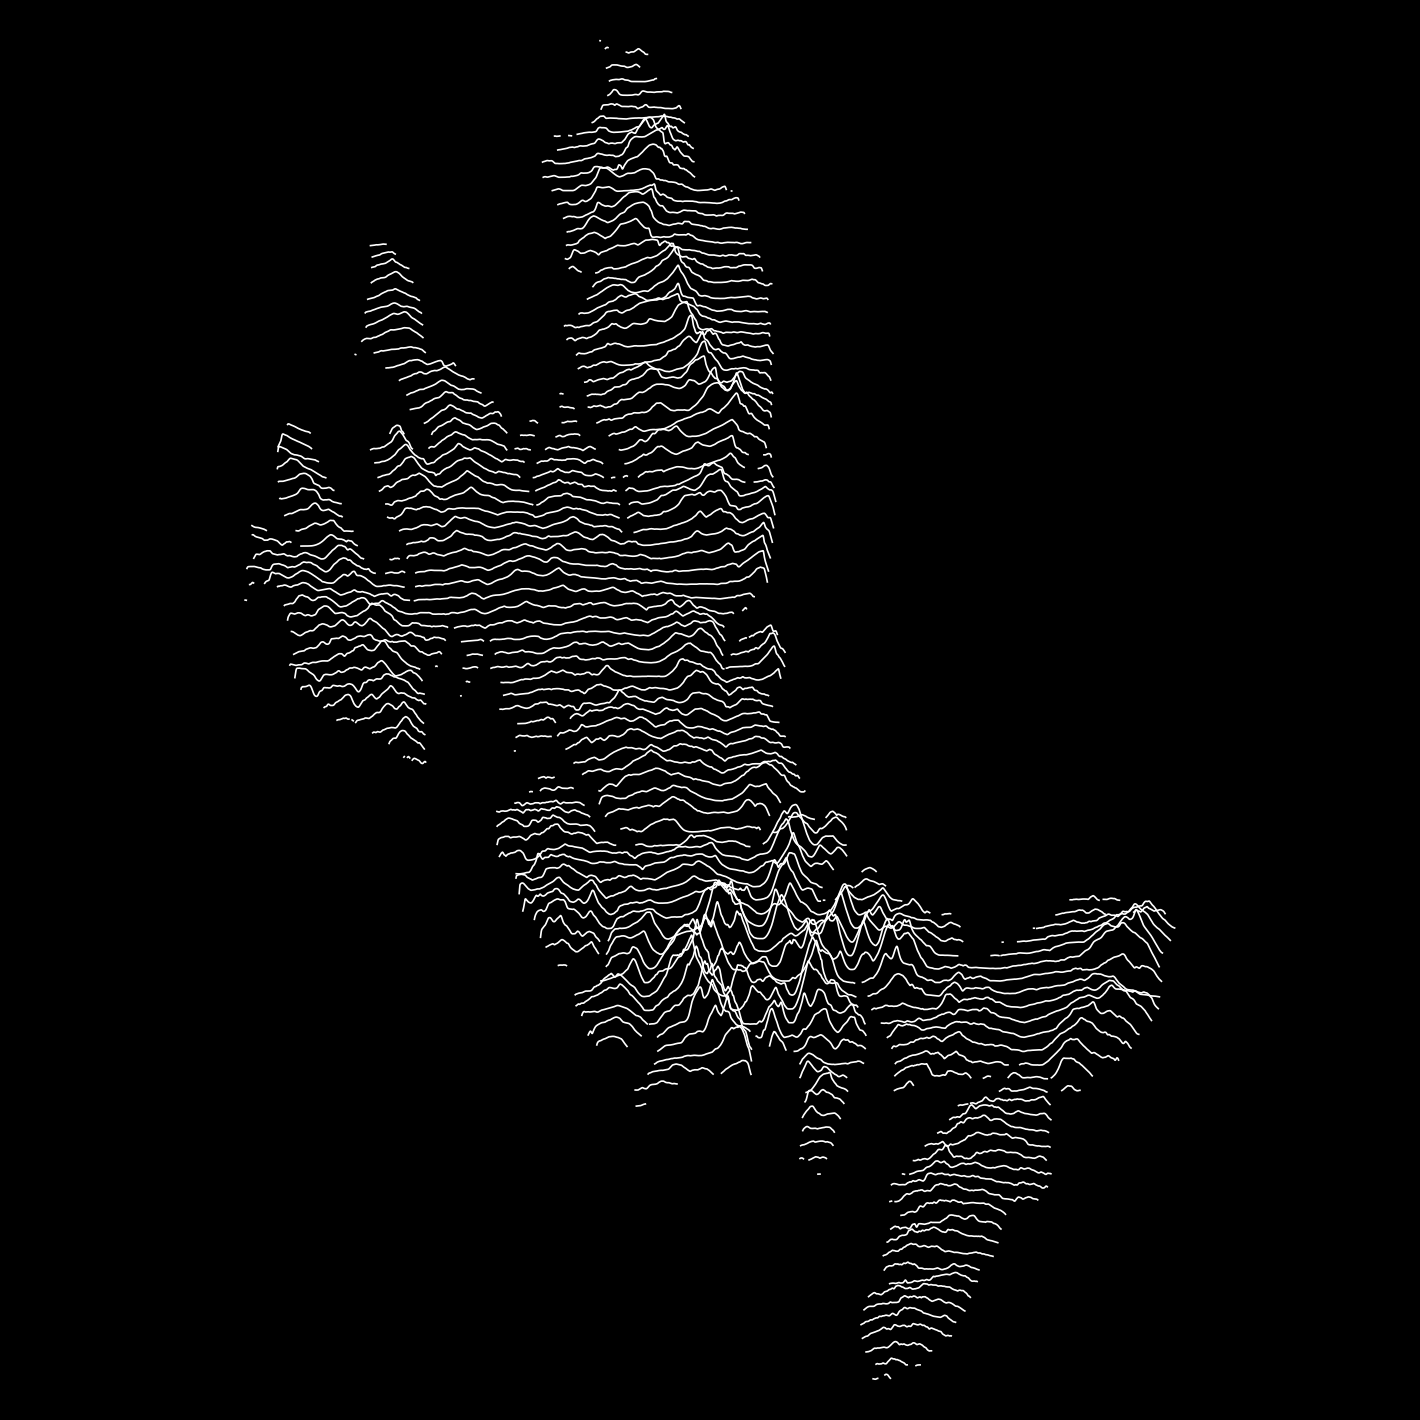

Visualization created with 100 profile lines
Saved to: IsleofSkye_Clipped_joy_plot.png


'IsleofSkye_Clipped_joy_plot.png'

In [99]:
create_joy_plot(
    raster_file="IsleofSkye_Clipped.tif",
    num_ridges=100,
    spacing=200,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25
)

Raster dimensions: 2031 rows x 3286 columns

Corner coordinates (in raster's CRS):
  Top-left:     (-3.50, 54.76)
  Top-right:    (-2.58, 54.76)
  Bottom-left:  (-3.50, 54.20)
  Bottom-right: (-2.58, 54.20)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


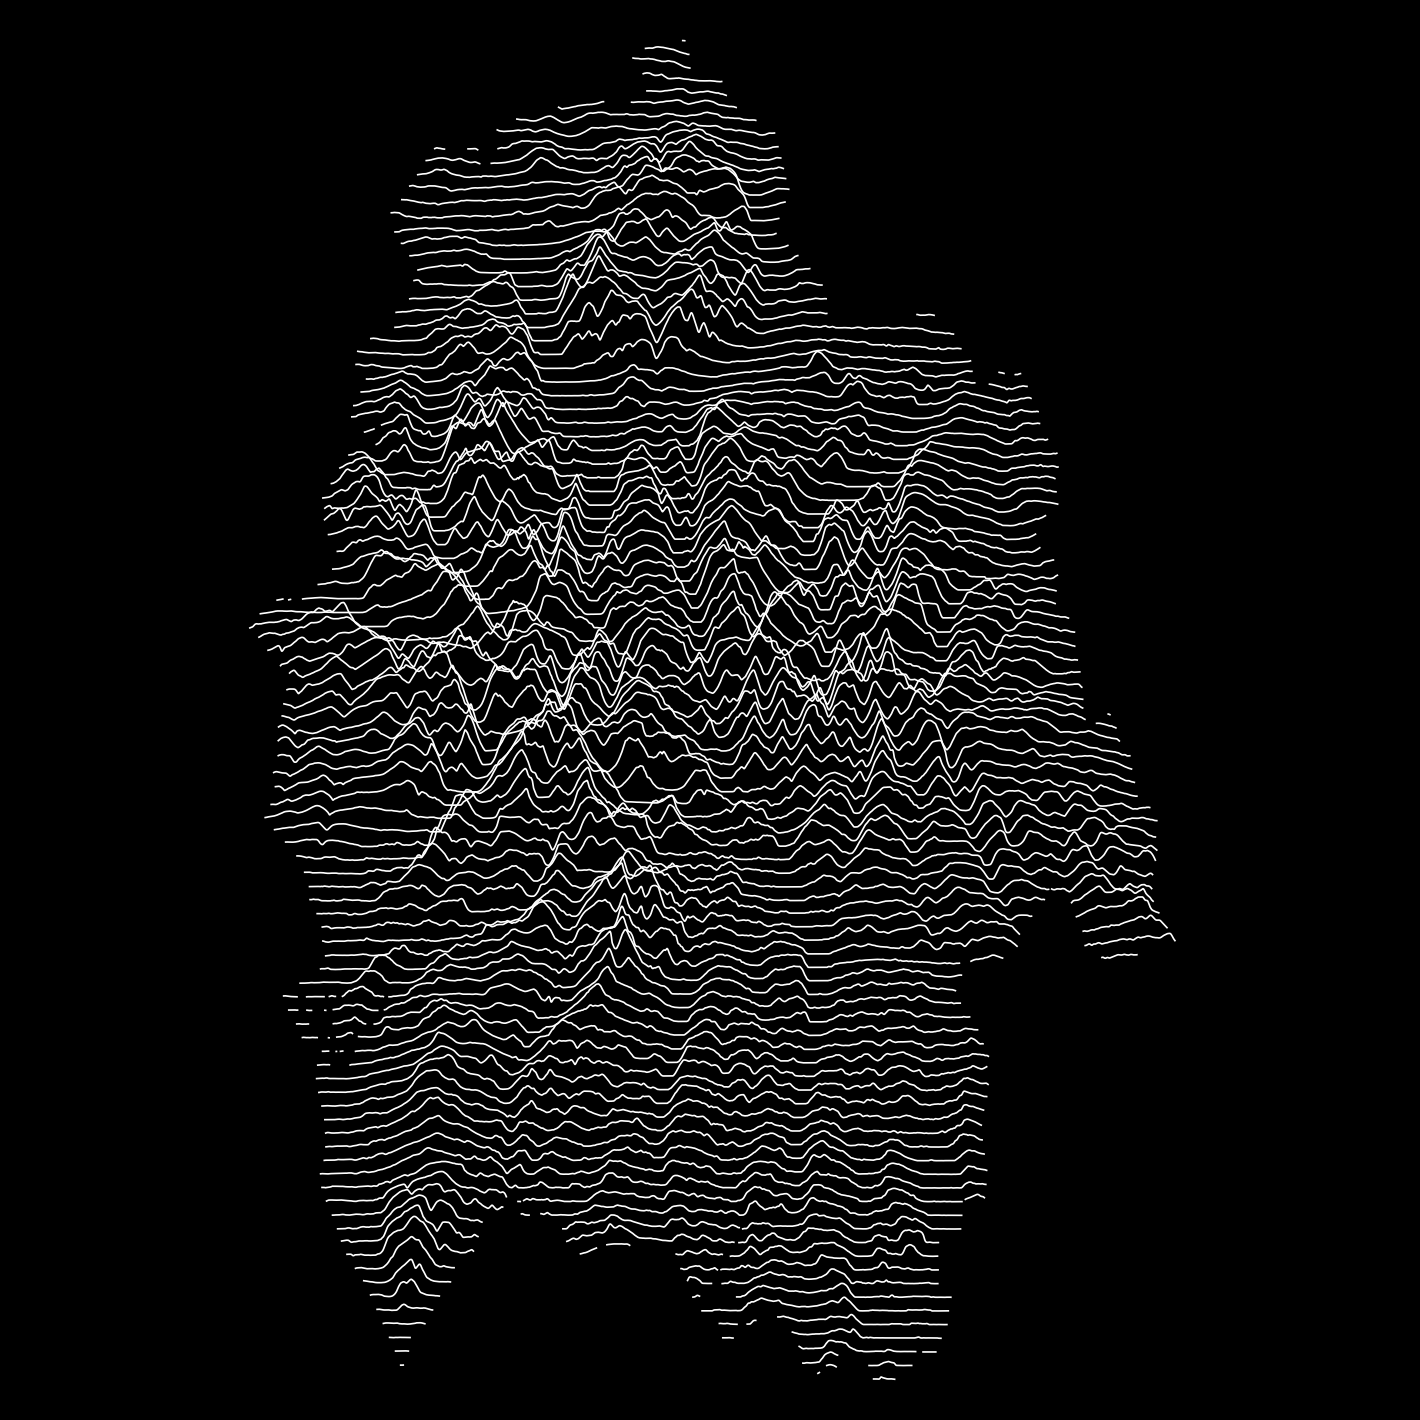

Visualization created with 100 profile lines
Saved to: LakeDistrict_Clipped_joy_plot.png


'LakeDistrict_Clipped_joy_plot.png'

In [103]:
create_joy_plot(
    raster_file="LakeDistrict_Clipped.tif",
    num_ridges=100,
    spacing=200,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25
)

Raster dimensions: 2029 rows x 2132 columns

Corner coordinates (in raster's CRS):
  Top-left:     (-2.11, 53.60)
  Top-right:    (-1.52, 53.60)
  Bottom-left:  (-2.11, 53.03)
  Bottom-right: (-1.52, 53.03)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


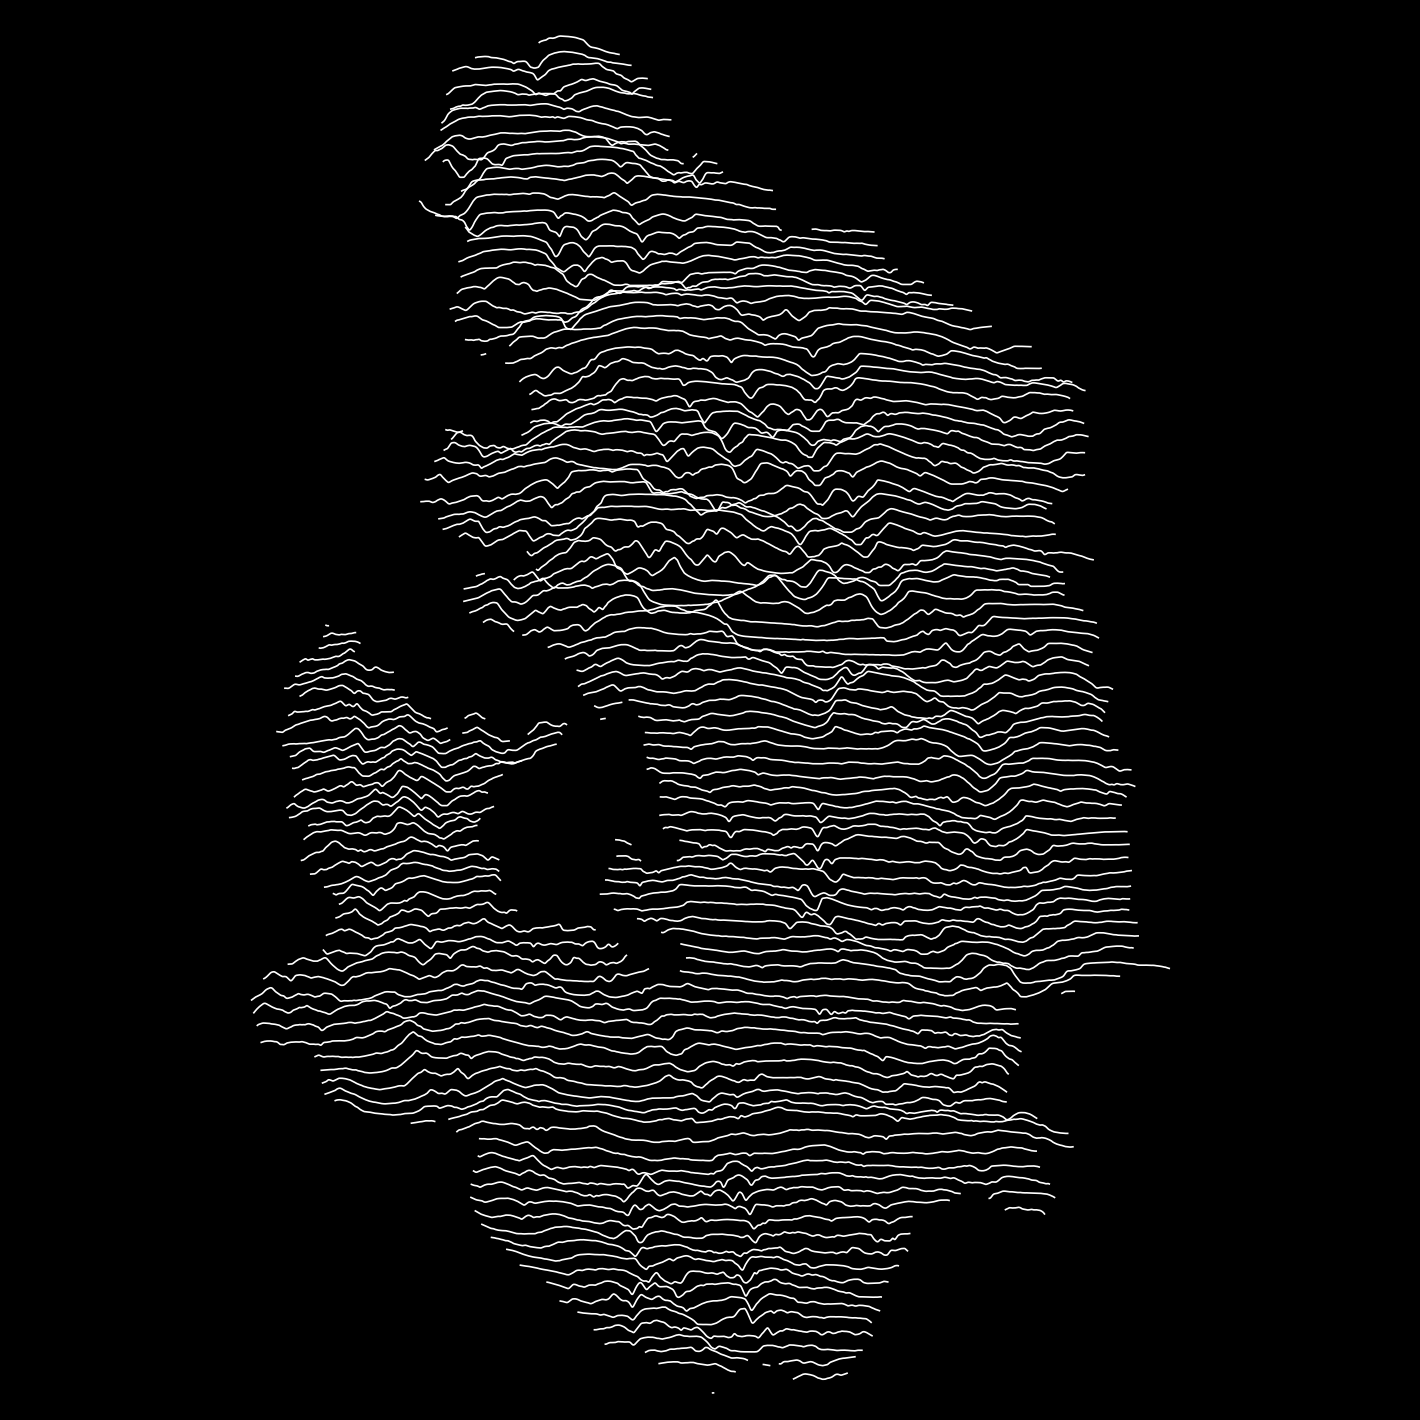

Visualization created with 100 profile lines
Saved to: PeakDistrict_Clipped_joy_plot.png


'PeakDistrict_Clipped_joy_plot.png'

In [111]:
create_joy_plot(
    raster_file="PeakDistrict_Clipped.tif",
    num_ridges=100,
    spacing=150,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25
)

Raster dimensions: 2692 rows x 2888 columns

Corner coordinates (in raster's CRS):
  Top-left:     (-4.28, 53.29)
  Top-right:    (-3.48, 53.29)
  Bottom-left:  (-4.28, 52.54)
  Bottom-right: (-3.48, 52.54)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


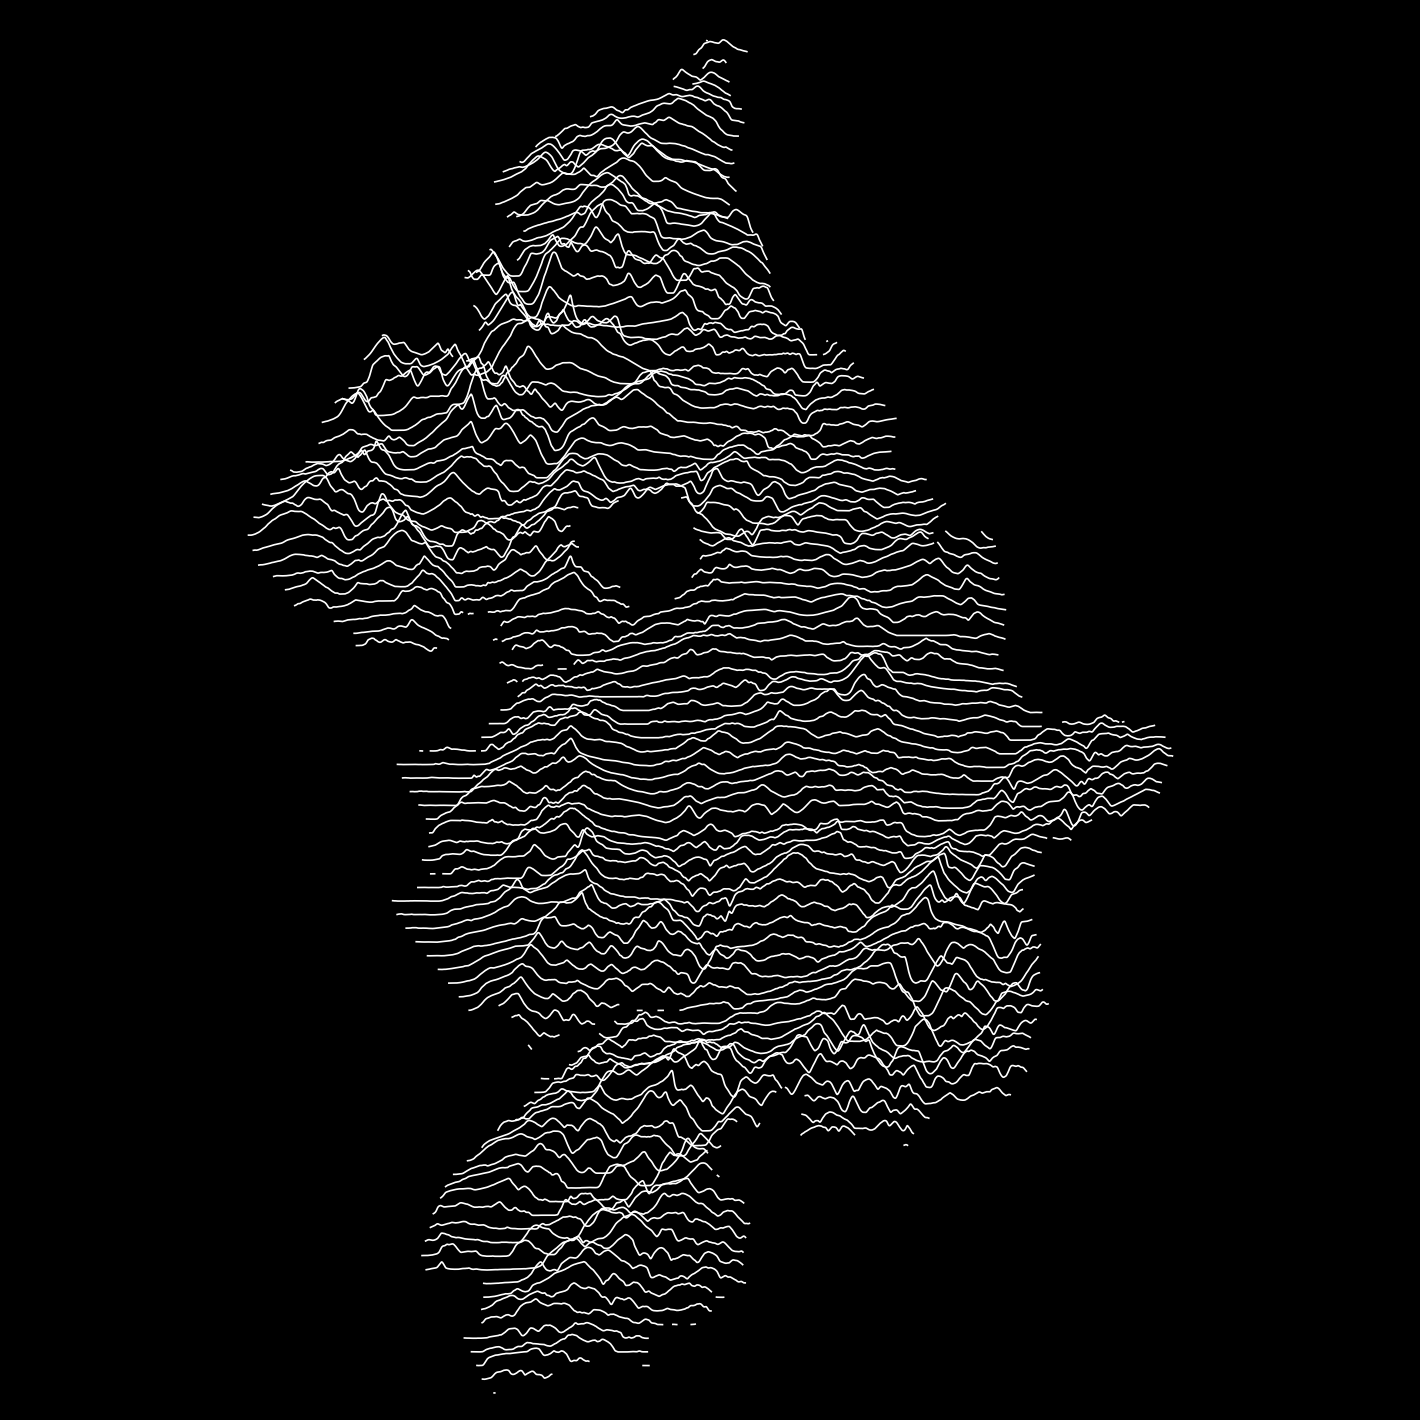

Visualization created with 100 profile lines
Saved to: Snowdonia_Clipped_joy_plot.png


'Snowdonia_Clipped_joy_plot.png'

In [113]:
create_joy_plot(
    raster_file="Snowdonia_Clipped.tif",
    num_ridges=100,
    spacing=200,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25
)

Raster dimensions: 1256 rows x 1922 columns

Corner coordinates (in raster's CRS):
  Top-left:     (-4.17, 50.74)
  Top-right:    (-3.63, 50.74)
  Bottom-left:  (-4.17, 50.39)
  Bottom-right: (-3.63, 50.39)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


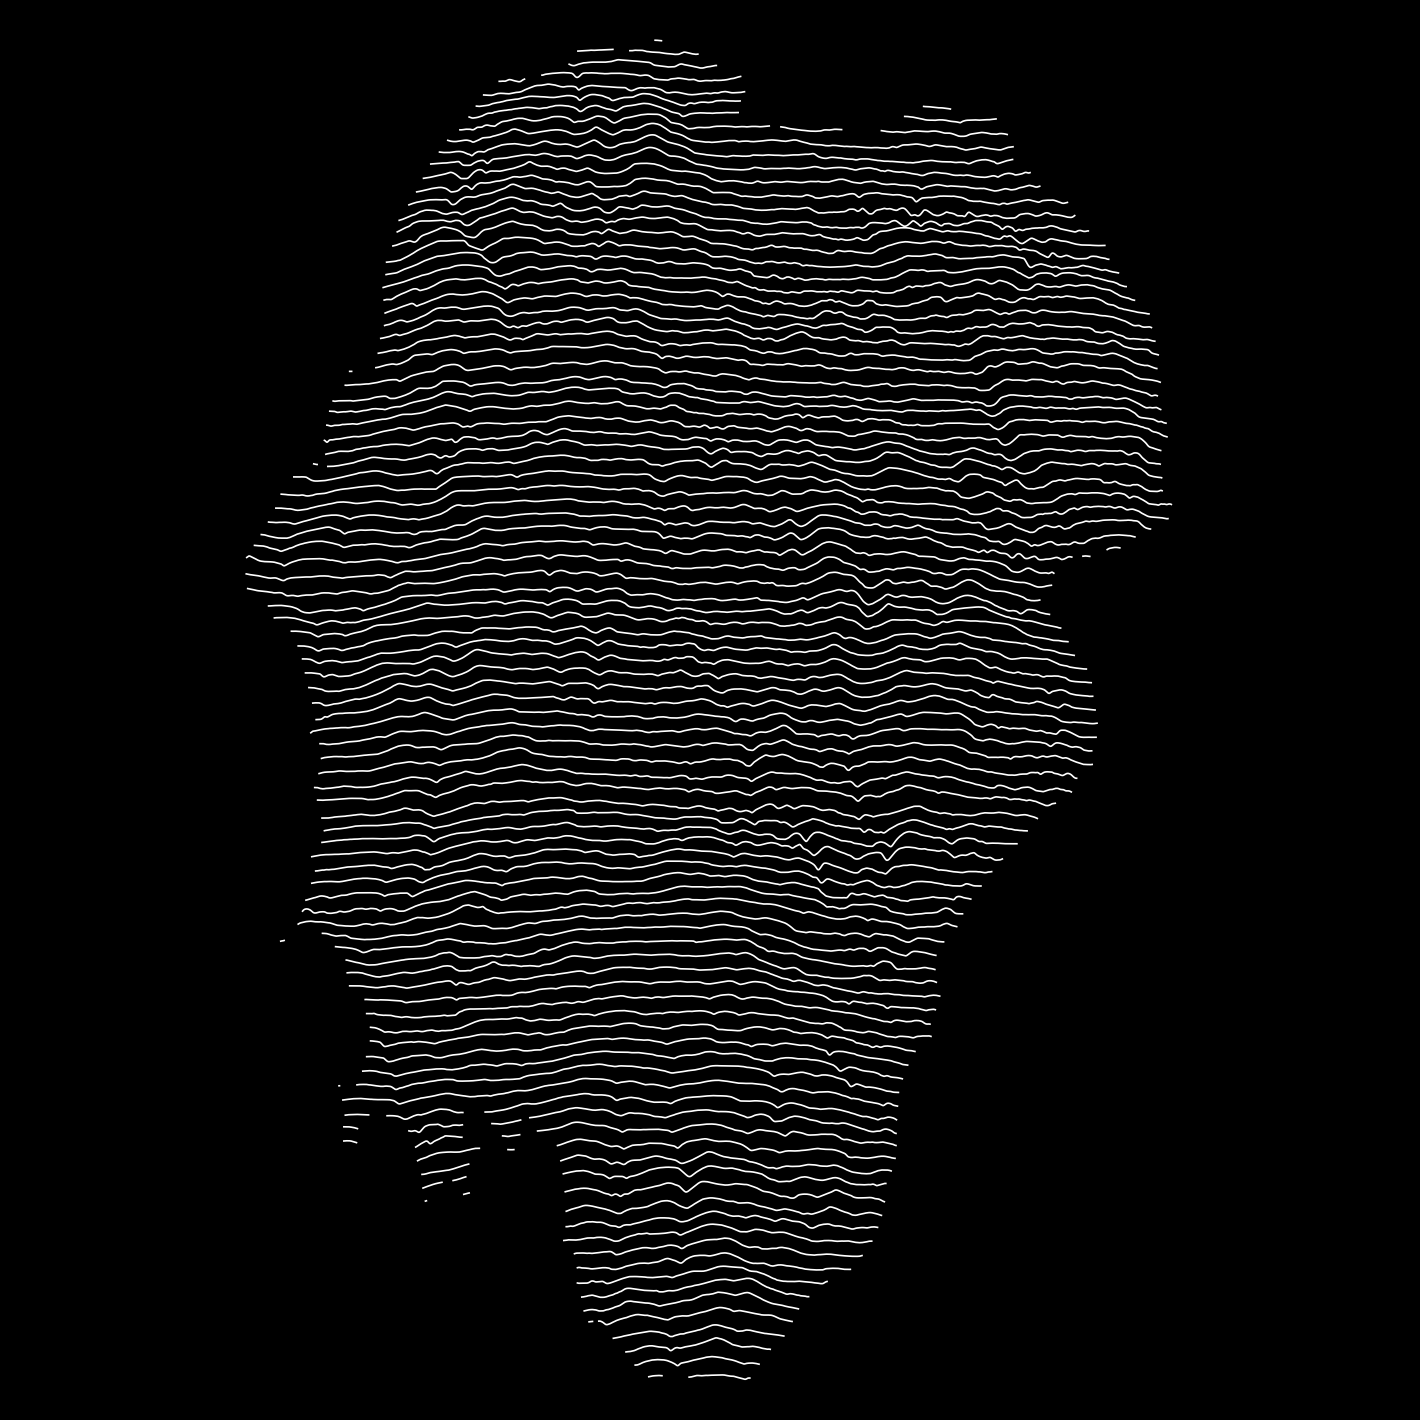

Visualization created with 100 profile lines
Saved to: Dartmoor_Clipped_joy_plot.png


'Dartmoor_Clipped_joy_plot.png'

In [125]:
create_joy_plot(
    raster_file="Dartmoor_Clipped.tif",
    num_ridges=100,
    spacing=200,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25,
)


Raster dimensions: 1210 rows x 1472 columns

Corner coordinates (in raster's CRS):
  Top-left:     (138.53, 35.57)
  Top-right:    (138.94, 35.57)
  Bottom-left:  (138.53, 35.24)
  Bottom-right: (138.94, 35.24)

Geographic orientation:
  X increases left-to-right: True
  Y increases top-to-bottom: False

For Joy plots viewing south→north:
  We want lower Y values at bottom of plot (foreground)
  We want higher Y values at top of plot (background)
✓ Auto-detect horizontal: no flip
✓ Auto-detect vertical: flip (for south→north view)


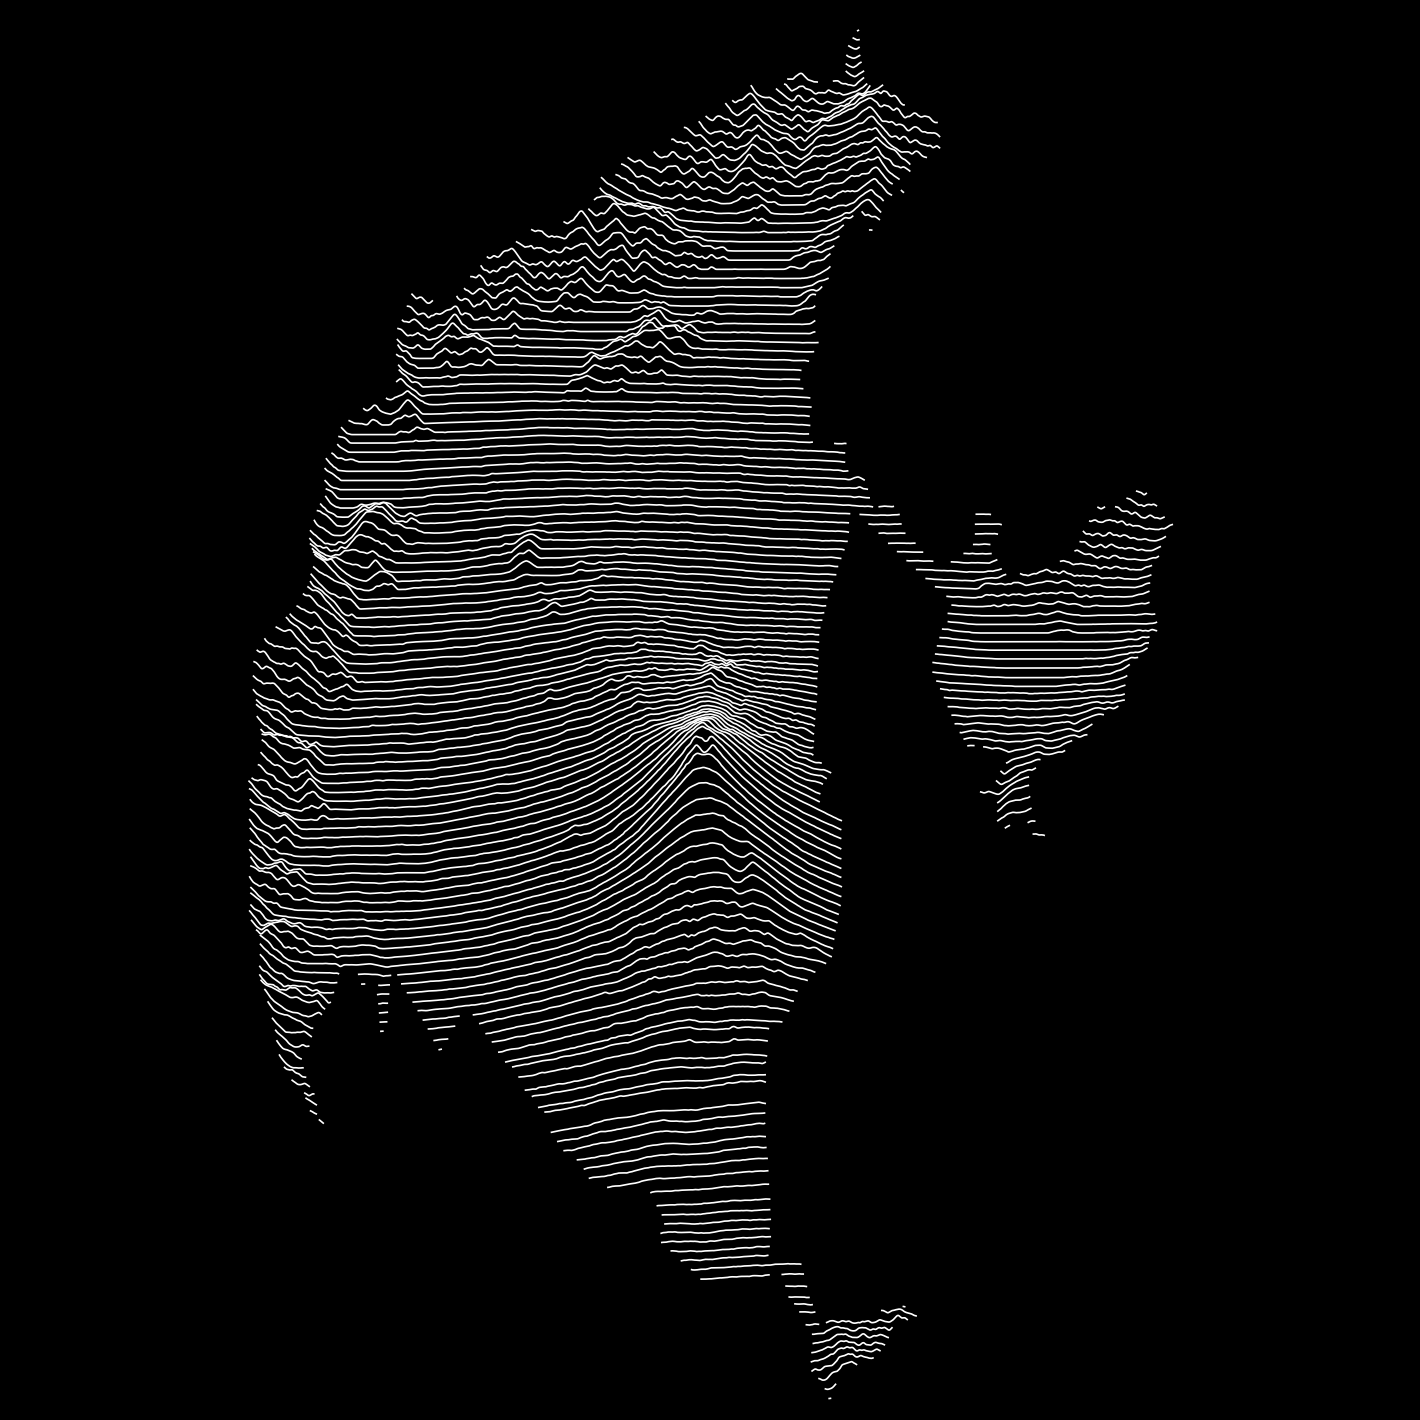

Visualization created with 150 profile lines
Saved to: Fuji-Hakone-Izu_Clipped_joy_plot.png


'Fuji-Hakone-Izu_Clipped_joy_plot.png'

In [152]:
create_joy_plot(
    raster_file="Fuji-Hakone-Izu_Clipped.tif",
    num_ridges=150,
    spacing=200,
    amplitude_scale=1.0,
    border_width=0.25,
    border_height=0.25,
)